# Real Estate Image Classifier
**Transfer Learning + Weights & Biases | PyTorch**

Pipeline:
1. Setup: dependencias, Drive y W&B
2. Exploración del dataset
3. Preprocesado y splits (train / val / test)
4. Clase `CNN` con transfer learning (estilo clase)
5. Entrenamiento baseline con W&B
6. Evaluación por clase (precision, recall, F1, confusion matrix)
7. W&B Sweep — búsqueda bayesiana de hiperparámetros
8. Evaluación final en Test set
9. Exportación del modelo para la API

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 0. Setup

In [3]:
# Verificar GPU
!nvidia-smi
!pip install -q wandb torchmetrics scikit-learn

Thu Apr 16 21:27:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import os, json, random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tempfile import TemporaryDirectory

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from torchmetrics.classification import (
    MulticlassPrecision, MulticlassRecall,
    MulticlassF1Score, MulticlassConfusionMatrix
)
import wandb

# ── Reproducibilidad ─────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {DEVICE}')

Usando: cuda


In [7]:
# Cerrar cualquier run abierto
wandb.finish()

# Limpiar y reiniciar
os.environ["WANDB_MODE"] = "online"
os.environ["WANDB_API_KEY"] = "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"

wandb.login(relogin=True)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 202521870 (202109933-universidad-pontificia-comillas) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 1. Dataset — exploración

Clases encontradas : 15
Total imágenes     : 2985

  Bedroom                          116 imágenes
  Coast                            260 imágenes
  Forest                           228 imágenes
  Highway                          160 imágenes
  Industrial                       211 imágenes
  Inside city                      208 imágenes
  Kitchen                          110 imágenes
  Living room                      189 imágenes
  Mountain                         274 imágenes
  Office                           115 imágenes
  Open country                     310 imágenes
  Store                            215 imágenes
  Street                           192 imágenes
  Suburb                           141 imágenes
  Tall building                    256 imágenes


/tmp/ipykernel_1360/2171564490.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_counts.keys(), rotation=45, ha='right')


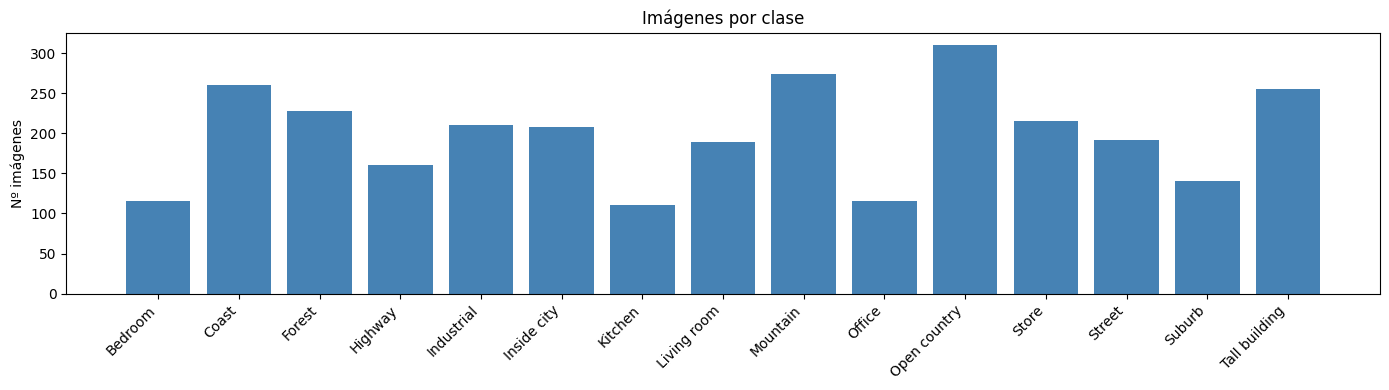

Ratio desbalance: 2.8x  (max=310, min=110)


In [8]:
# ─── AJUSTA esta ruta ────────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/dataset/training'

# Explorar estructura
class_counts = {}
for class_dir in sorted(Path(DATA_DIR).iterdir()):
    if class_dir.is_dir():
        n = len([f for f in class_dir.iterdir() if f.suffix.lower() in ('.jpg','.jpeg','.png','.webp')])
        class_counts[class_dir.name] = n

print(f'Clases encontradas : {len(class_counts)}')
print(f'Total imágenes     : {sum(class_counts.values())}')
print()
for cls, n in class_counts.items():
    print(f'  {cls:<30} {n:>5} imágenes')

# Gráfico de balance
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(class_counts.keys(), class_counts.values(), color='steelblue')
ax.set_title('Imágenes por clase')
ax.set_xticklabels(class_counts.keys(), rotation=45, ha='right')
ax.set_ylabel('Nº imágenes')
plt.tight_layout()
plt.show()

mx, mn = max(class_counts.values()), min(class_counts.values())
print(f'Ratio desbalance: {mx/mn:.1f}x  (max={mx}, min={mn})')

## 2. Preprocesado y splits estratificados (70 / 15 / 15)

In [9]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

TRAIN_DIR = '/content/drive/MyDrive/dataset/training'
VAL_DIR   = '/content/drive/MyDrive/dataset/validation'
train_ds     = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_test_ds  = datasets.ImageFolder(root=VAL_DIR,   transform=val_test_transforms)

CLASS_NAMES = train_ds.classes
NUM_CLASSES = len(CLASS_NAMES)

# Split estratificado sobre validation → 50% val / 50% test
val_targets = [s[1] for s in val_test_ds.samples]
val_indices = list(range(len(val_test_ds)))
val_idx, test_idx = train_test_split(
    val_indices, test_size=0.50, stratify=val_targets, random_state=SEED
)

print(f'Clases : {NUM_CLASSES}  →  {CLASS_NAMES}')
print(f'Train  : {len(train_ds):>5} imágenes')
print(f'Val    : {len(val_idx):>5} imágenes')
print(f'Test   : {len(test_idx):>5} imágenes')

def make_loaders(batch_size):
    tl = DataLoader(train_ds,                        batch_size=batch_size,
                    shuffle=True,  num_workers=2, pin_memory=True)
    vl = DataLoader(Subset(val_test_ds, val_idx),    batch_size=batch_size,
                    shuffle=False, num_workers=2, pin_memory=True)
    return tl, vl

test_loader = DataLoader(Subset(val_test_ds, test_idx), batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

Clases : 15  →  ['Bedroom', 'Coast', 'Forest', 'Highway', 'Industrial', 'Inside city', 'Kitchen', 'Living room', 'Mountain', 'Office', 'Open country', 'Store', 'Street', 'Suburb', 'Tall building']
Train  :  2985 imágenes
Val    :   750 imágenes
Test   :   750 imágenes


## 3. Clase CNN
Extendemos la clase vista en clase añadiendo:
- Soporte para múltiples backbones (`efficientnet_b3`, `resnet50`, `convnext_small`)
- Logging a W&B dentro de `train_model`
- Dropout configurable
- Método `evaluate_per_class` para métricas del informe


Lo que hace la función es lo siguiente:
- Fase 1 — Feature Extraction (5 épocas)
El backbone está completamente congelado. Solo se entrenan los pesos del clasificador que añadimos nosotros (el Linear final). Esto es rápido y estabiliza el clasificador antes de tocar el backbone. Se usa un LR alto porque solo hay pocos parámetros nuevos que ajustar.
- Fase 2 — Fine-tuning (10 épocas)
Llamamos a model.unfreeze(n) para descongelar las últimas N capas del backbone y dejamos que se ajusten con un LR mucho más bajo. Si usáramos el mismo LR alto del principio, destruiríamos los pesos preentrenados que ya son buenos.
- W&B logging
Cada época loguea train/loss, train/acc, val/loss, val/acc y el LR. Al final de cada run se loguea también la confusion matrix y las métricas por clase. Esto es lo que genera el historial de experimentos que pide el rubric.
- Compatibilidad con el Sweep
La función acepta config=None para runs manuales, pero cuando W&B Sweep la llama, le pasa automáticamente una configuración distinta en cada run — por eso toda la configuración viene de wandb.config y no está hardcodeada.

In [10]:
class CNN(nn.Module):
    """CNN con transfer learning para clasificación de imágenes inmobiliarias."""

    # ── Backbones soportados ──────────────────────────────────────────
    BACKBONES = {
        'efficientnet_b3': (
            lambda: models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT),
            lambda m: m.classifier[1].in_features,
            lambda m, head: setattr(m, 'classifier', head),
            lambda m: list(m.features.parameters()),
        ),
        'resnet50': (
            lambda: models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
            lambda m: m.fc.in_features,
            lambda m, head: setattr(m, 'fc', head),
            lambda m: list(m.parameters())[:-2],
        ),
        'convnext_small': (
            lambda: models.convnext_small(weights=models.ConvNeXt_Small_Weights.DEFAULT),
            lambda m: m.classifier[2].in_features,
            lambda m, head: m.classifier.__setitem__(2, head),
            lambda m: list(m.features.parameters()),
        ),
    }

    def __init__(self, backbone_name, num_classes, dropout=0.4,
                 unfreeze_layers=0, device=None):
        """
        Args:
            backbone_name   : 'efficientnet_b3' | 'resnet50' | 'convnext_small'
            num_classes     : número de clases de salida
            dropout         : tasa de dropout antes del clasificador
            unfreeze_layers : nº de capas del backbone a descongelar (0 = feature extraction)
            device          : torch.device (por defecto CUDA si está disponible)
        """
        super().__init__()
        assert backbone_name in self.BACKBONES, f'Backbone desconocido: {backbone_name}'

        self.backbone_name = backbone_name
        self.num_classes   = num_classes
        self.device        = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        build, get_in_features, set_head, get_backbone_params = self.BACKBONES[backbone_name]
        self.base_model = build()

        # Reemplazar cabeza clasificadora
        in_features = get_in_features(self.base_model)
        head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(in_features, num_classes)
        )
        set_head(self.base_model, head)

        # Congelar backbone completo
        self._backbone_params = get_backbone_params(self.base_model)
        for p in self._backbone_params:
            p.requires_grad = False

        # Descongelar últimas N capas si se indica
        if unfreeze_layers > 0:
            for p in self._backbone_params[-unfreeze_layers:]:
                p.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'[{backbone_name}] Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)')

        self.to(self.device)

    def forward(self, x):
        return self.base_model(x)

    def unfreeze(self, n_layers):
        """Descongelar las últimas n_layers del backbone para fine-tuning."""
        for p in self._backbone_params:
            p.requires_grad = False
        for p in self._backbone_params[-n_layers:]:
            p.requires_grad = True
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'Fine-tuning: {trainable:,} / {total:,} parámetros ({100*trainable/total:.1f}%)')

    # ──────────────────────────────────────────────────────────────────
    def train_model(self, train_loader, valid_loader, optimizer, criterion,
                    epochs, phase=1, use_wandb=True):
        """Entrena el modelo y guarda el mejor según val accuracy.

        Args:
            train_loader : DataLoader de entrenamiento
            valid_loader : DataLoader de validación
            optimizer    : optimizador
            criterion    : función de pérdida
            epochs       : número de épocas
            phase        : 1 (feature extraction) o 2 (fine-tuning) — para logging
            use_wandb    : si True, loguea métricas a W&B

        Returns:
            history: dict con listas de train/val loss y accuracy
        """
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

        with TemporaryDirectory() as tmp:
            best_path = os.path.join(tmp, 'best.pt')
            best_acc  = 0.0
            torch.save(self.state_dict(), best_path)

            history = {'train_loss': [], 'train_accuracy': [],
                       'valid_loss': [], 'valid_accuracy': []}

            for epoch in range(1, epochs + 1):
                # ── Train ──
                self.train()
                tr_loss, tr_correct, tr_total = 0.0, 0, 0
                for images, labels in train_loader:
                    images, labels = images.to(self.device), labels.to(self.device)
                    optimizer.zero_grad()
                    outputs = self(images)
                    loss    = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()
                    tr_loss    += loss.item() * images.size(0)
                    tr_correct += (outputs.argmax(1) == labels).sum().item()
                    tr_total   += images.size(0)

                tr_loss /= tr_total
                tr_acc   = tr_correct / tr_total

                # ── Validation ──
                self.eval()
                vl_loss, vl_correct, vl_total = 0.0, 0, 0
                with torch.no_grad():
                    for images, labels in valid_loader:
                        images, labels = images.to(self.device), labels.to(self.device)
                        outputs  = self(images)
                        loss     = criterion(outputs, labels)
                        vl_loss    += loss.item() * images.size(0)
                        vl_correct += (outputs.argmax(1) == labels).sum().item()
                        vl_total   += images.size(0)

                vl_loss /= vl_total
                vl_acc   = vl_correct / vl_total
                scheduler.step()

                history['train_loss'].append(tr_loss)
                history['train_accuracy'].append(tr_acc)
                history['valid_loss'].append(vl_loss)
                history['valid_accuracy'].append(vl_acc)

                print(f'  Phase {phase} | Epoch {epoch:02d}/{epochs} | '
                      f'train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | '
                      f'val_loss={vl_loss:.4f} val_acc={vl_acc:.3f}')

                if use_wandb:
                    wandb.log({
                        'phase'     : phase,
                        'epoch'     : (phase - 1) * epochs + epoch,
                        'train/loss': tr_loss, 'train/acc': tr_acc,
                        'val/loss'  : vl_loss, 'val/acc'  : vl_acc,
                        'lr'        : optimizer.param_groups[0]['lr'],
                    })

                if vl_acc > best_acc:
                    best_acc = vl_acc
                    torch.save(self.state_dict(), best_path)

            self.load_state_dict(torch.load(best_path, map_location=self.device))
            print(f'  ✓ Mejor val_acc en esta fase: {best_acc:.4f}')
            return history

    # ──────────────────────────────────────────────────────────────────
    def predict(self, data_loader):
        """Devuelve etiquetas predichas para todos los batches del loader."""
        self.eval()
        preds = []
        with torch.no_grad():
            for images, _ in data_loader:
                images = images.to(self.device)
                preds.extend(self(images).argmax(1).cpu().tolist())
        return preds

    # ──────────────────────────────────────────────────────────────────
    @torch.no_grad()
    def evaluate_per_class(self, data_loader, class_names):
        """Calcula precision, recall, F1 por clase y la confusion matrix.

        Returns:
            metrics : dict listo para wandb.log()
            cm      : numpy array (num_classes x num_classes)
        """
        self.eval()
        num_classes = len(class_names)
        all_preds, all_labels = [], []

        for images, labels in data_loader:
            images = images.to(self.device)
            all_preds.append(self(images).argmax(1).cpu())
            all_labels.append(labels)

        all_preds  = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)

        precision = MulticlassPrecision(num_classes=num_classes, average=None)(all_preds, all_labels)
        recall    = MulticlassRecall   (num_classes=num_classes, average=None)(all_preds, all_labels)
        f1        = MulticlassF1Score  (num_classes=num_classes, average=None)(all_preds, all_labels)
        cm        = MulticlassConfusionMatrix(num_classes=num_classes)(all_preds, all_labels).numpy()

        metrics = {}
        for i, cls in enumerate(class_names):
            metrics[f'per_class/precision_{cls}'] = precision[i].item()
            metrics[f'per_class/recall_{cls}']    = recall[i].item()
            metrics[f'per_class/f1_{cls}']        = f1[i].item()

        metrics['macro/precision'] = precision.mean().item()
        metrics['macro/recall']    = recall.mean().item()
        metrics['macro/f1']        = f1.mean().item()

        return metrics, cm

    # ──────────────────────────────────────────────────────────────────
    def save(self, path):
        """Guarda los pesos del modelo en disco."""
        os.makedirs(os.path.dirname(path), exist_ok=True)
        torch.save(self.state_dict(), path)
        print(f'Modelo guardado en {path}')

    @staticmethod
    def plot_training(history):
        """Dibuja las curvas de loss y accuracy."""
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        for ax, key, title in zip(axes,
                                  [('train_loss','valid_loss'),
                                   ('train_accuracy','valid_accuracy')],
                                  ['Loss', 'Accuracy']):
            ax.plot(history[key[0]], label='Train')
            ax.plot(history[key[1]], label='Val')
            ax.set_title(title); ax.set_xlabel('Epoch')
            ax.legend()
        plt.tight_layout()
        plt.show()

## 4. Entrenamiento baseline con W&B

In [11]:
def run_experiment(config=None):
    """
    Función principal de entrenamiento. Compatible con W&B Sweep.
    Entrena en 2 fases: feature extraction → fine-tuning.
    """
    default_config = dict(
        backbone        = 'efficientnet_b3',
        epochs_phase1   = 5,
        epochs_phase2   = 10,
        lr_phase1       = 1e-3,
        lr_phase2       = 1e-4,
        batch_size      = 32,
        dropout         = 0.4,
        unfreeze_layers = 20,
        weight_decay    = 1e-4,
        label_smoothing = 0.1,
    )

    run = wandb.init(
        project='real-estate-classifier',
        config=default_config if config is None else config,
        tags=['transfer-learning', 'pytorch']
    )
    cfg = wandb.config

    train_loader, valid_loader = make_loaders(cfg.batch_size)
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

    # ── FASE 1: Feature Extraction ────────────────────────────────────
    print('\n── Fase 1: Feature Extraction ──')
    model = CNN(
        backbone_name   = cfg.backbone,
        num_classes     = NUM_CLASSES,
        dropout         = cfg.dropout,
        unfreeze_layers = 0,           # backbone completamente congelado
    )
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.lr_phase1, weight_decay=cfg.weight_decay
    )
    model.train_model(train_loader, valid_loader, optimizer, criterion,
                      epochs=cfg.epochs_phase1, phase=1)

    # ── FASE 2: Fine-tuning ───────────────────────────────────────────
    print('\n── Fase 2: Fine-tuning ──')
    model.unfreeze(cfg.unfreeze_layers)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=cfg.lr_phase2, weight_decay=cfg.weight_decay
    )
    model.train_model(train_loader, valid_loader, optimizer, criterion,
                      epochs=cfg.epochs_phase2, phase=2)

    # ── Métricas por clase en validación ─────────────────────────────
    per_class_metrics, cm = model.evaluate_per_class(valid_loader, CLASS_NAMES)
    wandb.log(per_class_metrics)

    # Confusion matrix como imagen en W&B
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title('Confusion Matrix — Val')
    plt.colorbar(im); plt.tight_layout()
    wandb.log({'confusion_matrix': wandb.Image(fig)})
    plt.show()

    # Guardar modelo como artefacto W&B
    os.makedirs('/content/drive/MyDrive/TRABAJO_MACHINE_LEARNING_2/models/', exist_ok=True)
    model_path = f'/content/drive/MyDrive/TRABAJO_MACHINE_LEARNING_2/models/{wandb.run.name}.pth'
    model.save(model_path)
    artifact = wandb.Artifact('best-model', type='model')
    artifact.add_file(model_path)
    run.log_artifact(artifact)

    wandb.summary['best_val_acc'] = max(wandb.run.summary.get('val/acc', 0),
                                        per_class_metrics['macro/f1'])
    wandb.summary['macro_f1']     = per_class_metrics['macro/f1']
    run.finish()
    return model


── Fase 1: Feature Extraction ──
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 161MB/s]


[efficientnet_b3] Parámetros entrenables: 23,055 / 10,719,287 (0.2%)
  Phase 1 | Epoch 01/5 | train_loss=1.9630 train_acc=0.538 | val_loss=1.4166 val_acc=0.805
  Phase 1 | Epoch 02/5 | train_loss=1.3534 train_acc=0.759 | val_loss=1.1556 val_acc=0.844
  Phase 1 | Epoch 03/5 | train_loss=1.2087 train_acc=0.797 | val_loss=1.0848 val_acc=0.857
  Phase 1 | Epoch 04/5 | train_loss=1.1569 train_acc=0.804 | val_loss=1.0583 val_acc=0.856
  Phase 1 | Epoch 05/5 | train_loss=1.1422 train_acc=0.806 | val_loss=1.0565 val_acc=0.855
  ✓ Mejor val_acc en esta fase: 0.8573

── Fase 2: Fine-tuning ──
Fine-tuning: 3,397,599 / 10,719,287 parámetros (31.7%)
  Phase 2 | Epoch 01/10 | train_loss=1.1044 train_acc=0.815 | val_loss=0.9816 val_acc=0.864
  Phase 2 | Epoch 02/10 | train_loss=1.0268 train_acc=0.838 | val_loss=0.9535 val_acc=0.879
  Phase 2 | Epoch 03/10 | train_loss=0.9815 train_acc=0.862 | val_loss=0.9293 val_acc=0.876
  Phase 2 | Epoch 04/10 | train_loss=0.9442 train_acc=0.875 | val_loss=0.9132 v

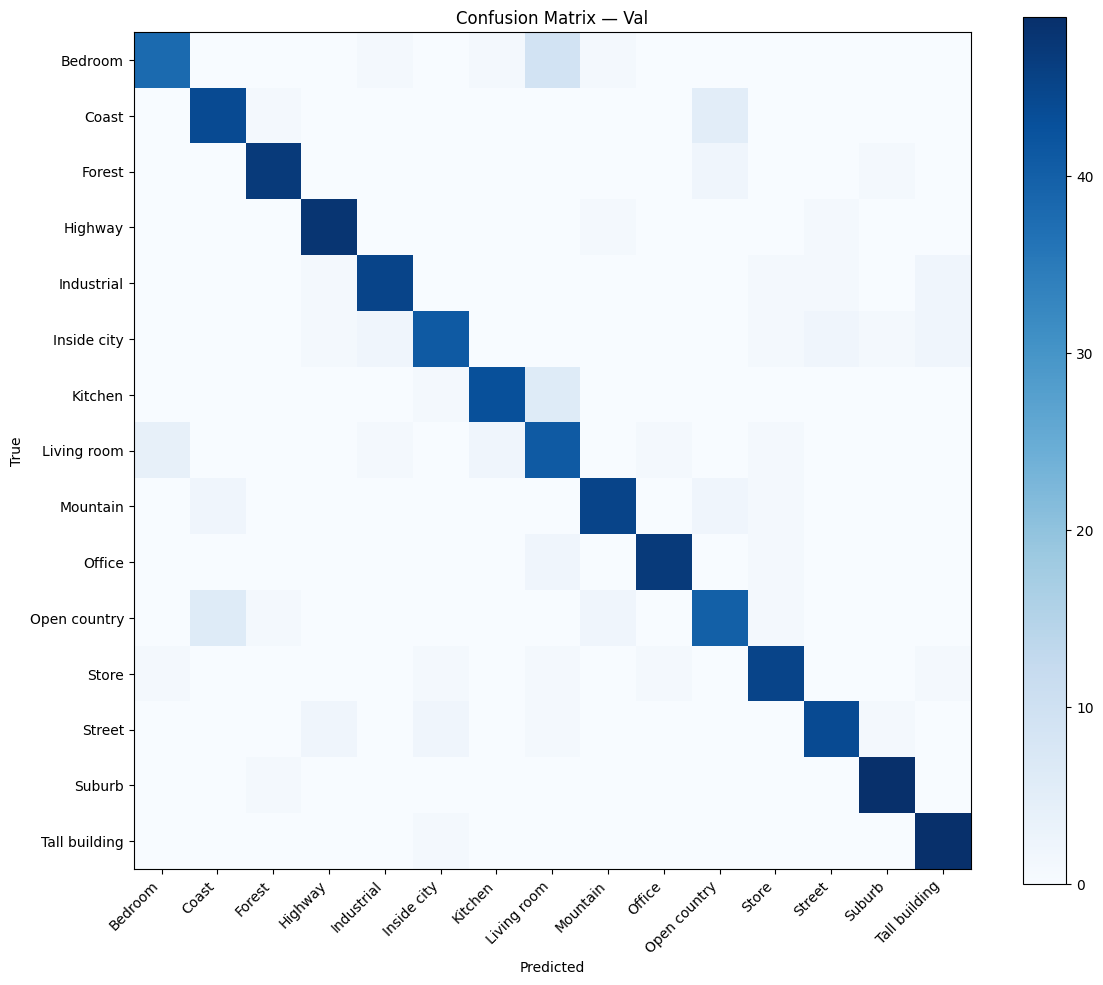

Modelo guardado en /content/drive/MyDrive/TRABAJO_MACHINE_LEARNING_2/models/eager-river-20.pth


epoch,▁▁▂▂▂▅▅▅▆▆▇▇▇██
lr,█▆▄▂▁▂▂▂▂▁▁▁▁▁▁
macro/f1,▁
macro/precision,▁
macro/recall,▁
per_class/f1_Bedroom,▁
per_class/f1_Coast,▁
per_class/f1_Forest,▁
per_class/f1_Highway,▁
per_class/f1_Industrial,▁
+45,...


In [ ]:
# ─── Ejecutar baseline ───────────────────────────────────────────────
model = run_experiment()

## 5. W&B Sweep — Búsqueda bayesiana de hiperparámetros
Ejecuta esto una vez que el baseline funciona correctamente.

In [ ]:
sweep_config = {
    'method': 'bayes',
    'metric': {'name': 'val/acc', 'goal': 'maximize'},
    'parameters': {
        'backbone'       : {'values': ['efficientnet_b3', 'resnet50', 'convnext_small']},
        'lr_phase1'      : {'distribution': 'log_uniform_values', 'min': 1e-4, 'max': 1e-2},
        'lr_phase2'      : {'distribution': 'log_uniform_values', 'min': 1e-5, 'max': 1e-3},
        'dropout'        : {'values': [0.2, 0.3, 0.4, 0.5]},
        'batch_size'     : {'values': [16, 32, 64]},
        'unfreeze_layers': {'values': [10, 20, 40]},
        'weight_decay'   : {'distribution': 'log_uniform_values', 'min': 1e-5, 'max': 1e-2},
        'label_smoothing': {'values': [0.0, 0.1, 0.2]},
        'epochs_phase1'  : {'value': 5},
        'epochs_phase2'  : {'value': 10},
    }
}

sweep_id = wandb.sweep(sweep_config, project='real-estate-classifier')
print(f'Sweep ID: {sweep_id}')

Create sweep with ID: 8ntzldx4
Sweep URL: https://wandb.ai/202109933-universidad-pontificia-comillas/real-estate-classifier/sweeps/8ntzldx4
Sweep ID: 8ntzldx4


wandb: Agent Starting Run: mu97bj1o with config:
wandb: 	backbone: convnext_small
wandb: 	batch_size: 32
wandb: 	dropout: 0.2
wandb: 	epochs_phase1: 5
wandb: 	epochs_phase2: 10
wandb: 	label_smoothing: 0.1
wandb: 	lr_phase1: 0.002820235028488546
wandb: 	lr_phase2: 4.205007793656896e-05
wandb: 	unfreeze_layers: 10
wandb: 	weight_decay: 1.4029333384149264e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.



── Fase 1: Feature Extraction ──
Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /root/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:02<00:00, 95.5MB/s]


[convnext_small] Parámetros entrenables: 13,071 / 49,466,223 (0.0%)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Phase 1 | Epoch 01/5 | train_loss=1.0356 train_acc=0.851 | val_loss=0.8143 val_acc=0.936
  Phase 1 | Epoch 02/5 | train_loss=0.8097 train_acc=0.924 | val_loss=0.7929 val_acc=0.936
  Phase 1 | Epoch 03/5 | train_loss=0.7764 train_acc=0.946 | val_loss=0.7845 val_acc=0.944
  Phase 1 | Epoch 04/5 | train_loss=0.7634 train_acc=0.946 | val_loss=0.7716 val_acc=0.944
  Phase 1 | Epoch 05/5 | train_loss=0.7434 train_acc=0.954 | val_loss=0.7712 val_acc=0.941
  ✓ Mejor val_acc en esta fase: 0.9440

── Fase 2: Fine-tuning ──
Fine-tuning: 4,776,975 / 49,466,223 parámetros (9.7%)
  Phase 2 | Epoch 01/10 | train_loss=0.7629 train_acc=0.946 | val_loss=0.7735 val_acc=0.944
  Phase 2 | Epoch 02/10 | train_loss=0.7576 train_acc=0.950 | val_loss=0.7693 val_acc=0.947
  Phase 2 | Epoch 03/10 | train_loss=0.7510 train_acc=0.952 | val_loss=0.7655 val_acc=0.945
  Phase 2 | Epoch 04/10 | train_loss=0.7410 train_acc=0.958 | val_loss=0.7630 val_acc=0.948
  Phase 2 | Epoch 05/10 | train_loss=0.7426 train_acc=0.9

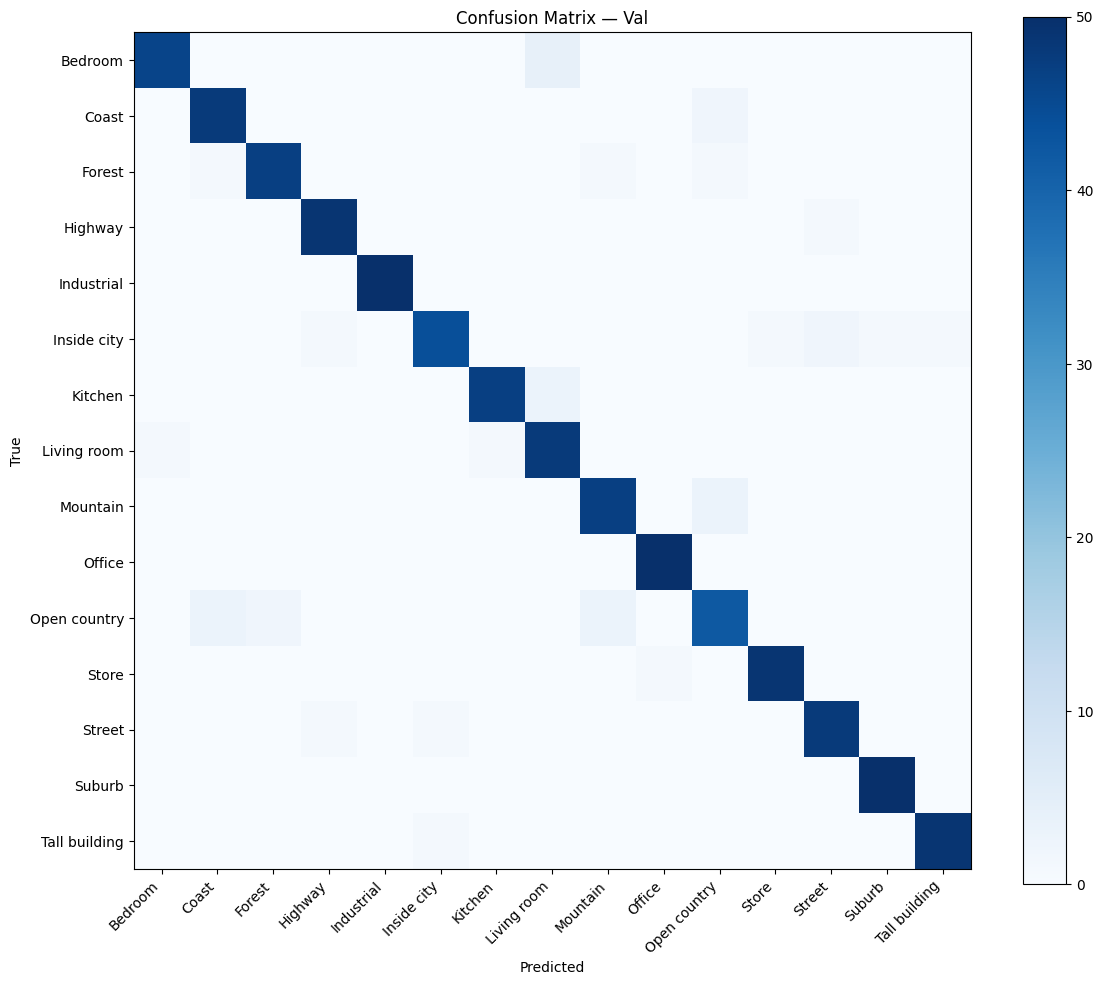

Modelo guardado en /content/drive/MyDrive/TRABAJO_MACHINE_LEARNING_2/models/smooth-sweep-1.pth


epoch,▁▁▂▂▂▅▅▅▆▆▇▇▇██
lr,█▆▄▂▁▁▁▁▁▁▁▁▁▁▁
macro/f1,▁
macro/precision,▁
macro/recall,▁
per_class/f1_Bedroom,▁
per_class/f1_Coast,▁
per_class/f1_Forest,▁
per_class/f1_Highway,▁
per_class/f1_Industrial,▁
+45,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: fnyjw5f4 with config:
wandb: 	backbone: convnext_small
wandb: 	batch_size: 64
wandb: 	dropout: 0.2
wandb: 	epochs_phase1: 5
wandb: 	epochs_phase2: 10
wandb: 	label_smoothing: 0.1
wandb: 	lr_phase1: 0.0003078537717190681
wandb: 	lr_phase2: 0.0002233488041754591
wandb: 	unfreeze_layers: 10
wandb: 	weight_decay: 1.0732613302085646e-05
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.



── Fase 1: Feature Extraction ──
[convnext_small] Parámetros entrenables: 13,071 / 49,466,223 (0.0%)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  Phase 1 | Epoch 01/5 | train_loss=2.1114 train_acc=0.482 | val_loss=1.5319 val_acc=0.801
  Phase 1 | Epoch 02/5 | train_loss=1.3777 train_acc=0.823 | val_loss=1.1105 val_acc=0.864
  Phase 1 | Epoch 03/5 | train_loss=1.1272 train_acc=0.868 | val_loss=0.9841 val_acc=0.880
  Phase 1 | Epoch 04/5 | train_loss=1.0302 train_acc=0.885 | val_loss=0.9450 val_acc=0.885
  Phase 1 | Epoch 05/5 | train_loss=0.9939 train_acc=0.896 | val_loss=0.9356 val_acc=0.888
  ✓ Mejor val_acc en esta fase: 0.8880

── Fase 2: Fine-tuning ──
Fine-tuning: 4,776,975 / 49,466,223 parámetros (9.7%)
  Phase 2 | Epoch 01/10 | train_loss=0.9098 train_acc=0.896 | val_loss=0.8175 val_acc=0.915
  Phase 2 | Epoch 02/10 | train_loss=0.8312 train_acc=0.923 | val_loss=0.7789 val_acc=0.925
  Phase 2 | Epoch 03/10 | train_loss=0.8052 train_acc=0.933 | val_loss=0.7560 val_acc=0.941


In [ ]:
# count=N controla cuántos runs lanza esta sesión.
# Puedes abrir otro Colab con el mismo sweep_id para paralelizar.
wandb.agent(sweep_id, function=run_experiment, count=20)

In [ ]:
import wandb

api = wandb.Api()
runs = api.runs("202109933-universidad-pontificia-comillas/real-estate-classifier")

# Ordenar por val/acc
results = []
for run in runs:
    if run.state == "finished":
        results.append({
            'name'           : run.name,
            'backbone'       : run.config.get('backbone', '-'),
            'lr_phase2'      : run.config.get('lr_phase2', '-'),
            'dropout'        : run.config.get('dropout', '-'),
            'batch_size'     : run.config.get('batch_size', '-'),
            'unfreeze_layers': run.config.get('unfreeze_layers', '-'),
            'val_acc'        : run.summary.get('val/acc', 0),
            'macro_f1'       : run.summary.get('macro/f1', 0),
        })

results.sort(key=lambda x: x['val_acc'], reverse=True)

print(f"{'Run':<30} {'Backbone':<20} {'val_acc':>8} {'macro_f1':>9} {'dropout':>8} {'batch':>6} {'unfreeze':>9}")
print("-" * 100)
for r in results[:10]:  # Top 10
    print(f"{r['name']:<30} {r['backbone']:<20} {r['val_acc']:>8.4f} {r['macro_f1']:>9.4f} "
          f"{r['dropout']:>8} {r['batch_size']:>6} {r['unfreeze_layers']:>9}")

Run                            Backbone              val_acc  macro_f1  dropout  batch  unfreeze
----------------------------------------------------------------------------------------------------
comfy-sweep-9                  -                      0.9720    0.9720        -      -         -
scarlet-sweep-14               -                      0.9720    0.9746        -      -         -
quiet-sweep-19                 -                      0.9720    0.9720        -      -         -
neat-sweep-20                  -                      0.9693    0.9693        -      -         -
lilac-sweep-20                 -                      0.9693    0.9734        -      -         -
eager-sweep-10                 -                      0.9667    0.9666        -      -         -
spring-sweep-11                -                      0.9667    0.9667        -      -         -
fallen-sweep-16                -                      0.9653    0.9653        -      -         -
celestial-sweep-18        

El sweep se usó para identificar la configuración óptima de hiperparámetros. Una vez seleccionado el mejor run por macro_F1(scarlet-sweep-14 porque tiene el mayor macro_f1 (0.9746) entre los runs empatados en val_acc (0.9720)), se realizó un entrenamiento final reproducible con esa configuración, añadiendo 5 épocas adicionales para asegurar la convergencia del modelo.
Reentrenamos con la config



── Fase 1: Feature Extraction ──
Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /root/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:01<00:00, 173MB/s]


[convnext_small] Parámetros entrenables: 13,071 / 49,466,223 (0.0%)
  Phase 1 | Epoch 01/5 | train_loss=2.5079 train_acc=0.245 | val_loss=2.1805 val_acc=0.527
  Phase 1 | Epoch 02/5 | train_loss=2.0082 train_acc=0.588 | val_loss=1.7569 val_acc=0.748
  Phase 1 | Epoch 03/5 | train_loss=1.7025 train_acc=0.747 | val_loss=1.5306 val_acc=0.813
  Phase 1 | Epoch 04/5 | train_loss=1.5539 train_acc=0.792 | val_loss=1.4325 val_acc=0.829
  Phase 1 | Epoch 05/5 | train_loss=1.4999 train_acc=0.810 | val_loss=1.4078 val_acc=0.833
  ✓ Mejor val_acc en esta fase: 0.8333

── Fase 2: Fine-tuning ──
Fine-tuning: 16,685,583 / 49,466,223 parámetros (33.7%)
  Phase 2 | Epoch 01/15 | train_loss=0.8890 train_acc=0.892 | val_loss=0.7623 val_acc=0.940
  Phase 2 | Epoch 02/15 | train_loss=0.7381 train_acc=0.940 | val_loss=0.6863 val_acc=0.959
  Phase 2 | Epoch 03/15 | train_loss=0.6838 train_acc=0.962 | val_loss=0.6993 val_acc=0.955
  Phase 2 | Epoch 04/15 | train_loss=0.6585 train_acc=0.972 | val_loss=0.6817 v

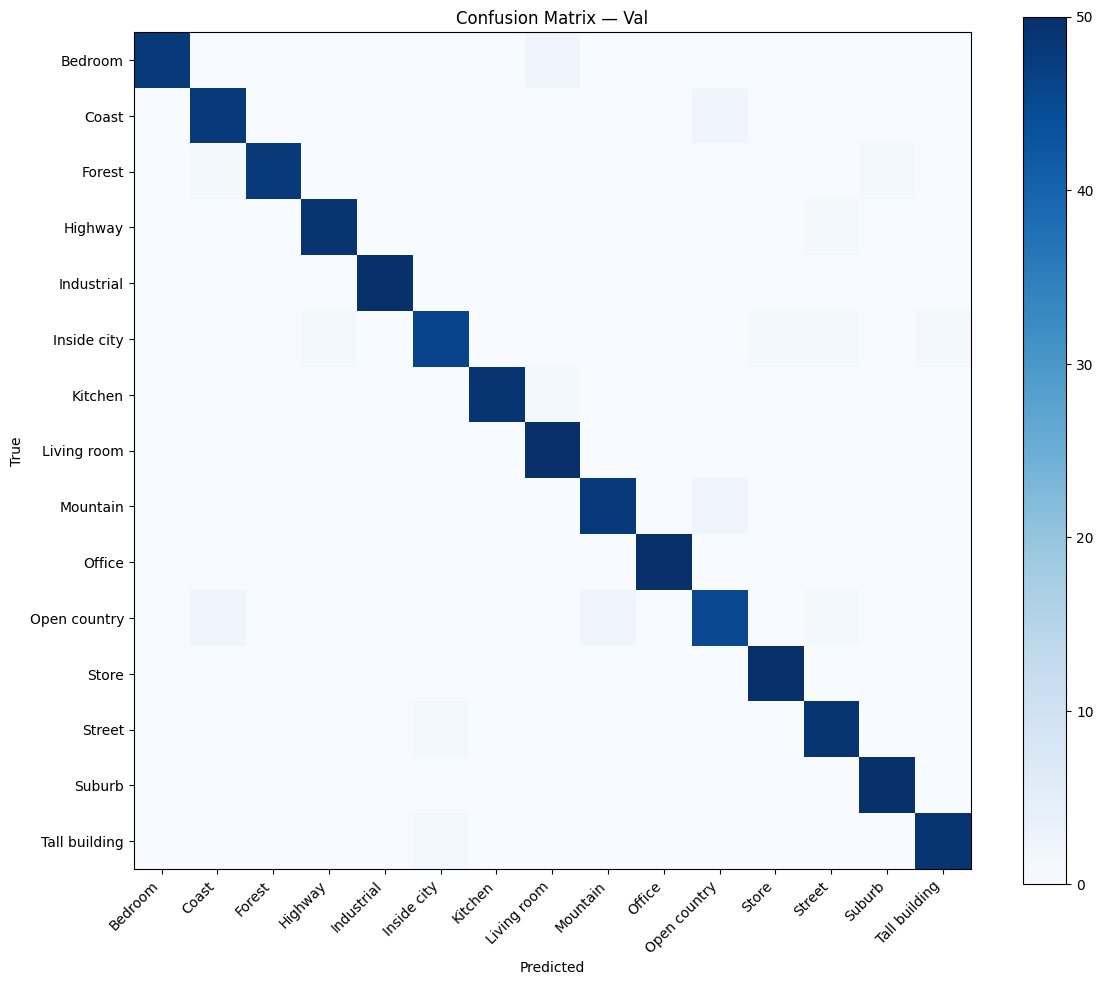

Modelo guardado en /content/drive/MyDrive/TRABAJO_MACHINE_LEARNING_2/models/winter-surf-49.pth


epoch,▁▁▁▂▂▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▃▂▂▁▁██▇▇▆▆▅▄▃▃▂▂▁▁▁
macro/f1,▁
macro/precision,▁
macro/recall,▁
per_class/f1_Bedroom,▁
per_class/f1_Coast,▁
per_class/f1_Forest,▁
per_class/f1_Highway,▁
per_class/f1_Industrial,▁
+45,...


In [12]:
best_config = dict(
    backbone        = 'convnext_small',
    epochs_phase1   = 5,
    epochs_phase2   = 15,               # +5 épocas extra para el modelo final
    lr_phase1       = 0.00013378952213775647,
    lr_phase2       = 0.0005161874191227735,
    batch_size      = 64,
    dropout         = 0.2,
    unfreeze_layers = 40,
    weight_decay    = 0.0021954901374285313,
    label_smoothing = 0.1,
)

final_model = run_experiment(config=best_config)

## 6. Evaluación final en Test set
Ejecuta **solo una vez** con el mejor modelo del sweep.

[convnext_small] Parámetros entrenables: 13,071 / 49,466,223 (0.0%)



=== TEST SET RESULTS ===
Accuracy         : 0.9747
Macro F1         : 0.9745
Macro Precision  : 0.9750
Macro Recall     : 0.9747

Clase                           Precision     Recall         F1
-----------------------------------------------------------------
Bedroom                             0.980      0.980      0.980
Coast                               0.961      0.980      0.970
Forest                              1.000      0.960      0.980
Highway                             0.961      0.980      0.970
Industrial                          1.000      0.980      0.990
Inside city                         0.979      0.940      0.959
Kitchen                             0.962      1.000      0.980
Living room                         0.980      0.980      0.980
Mountain                            0.943      1.000      0.971
Office                              1.000      0.980      0.990
Open country                        0.957      0.880      0.917
Store                              

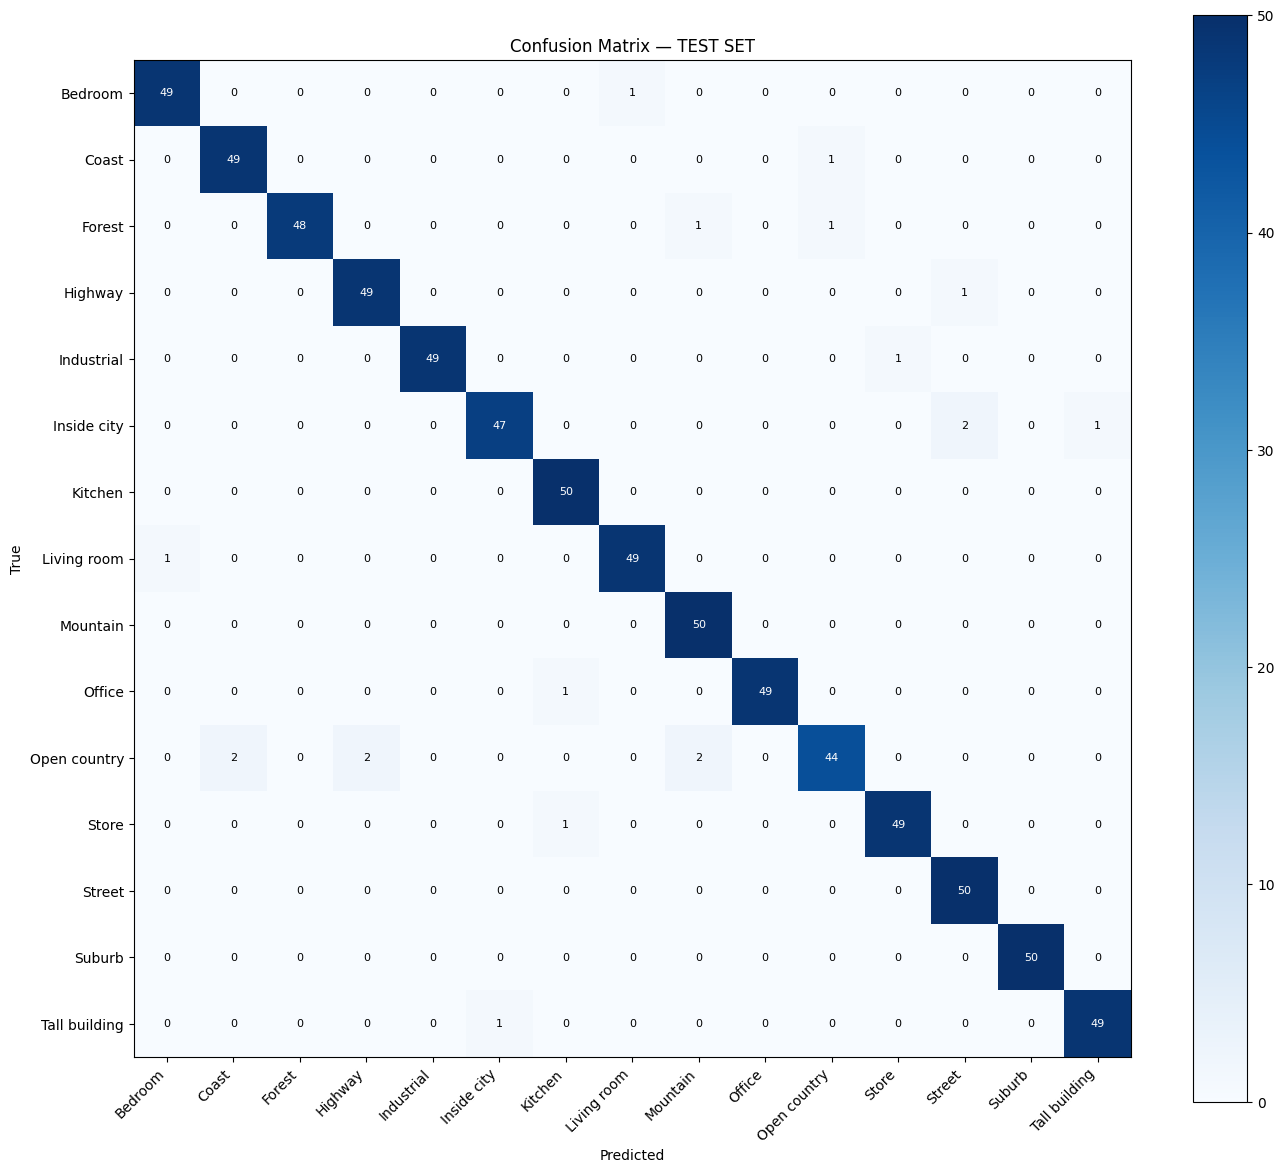

macro/f1,▁
macro/precision,▁
macro/recall,▁
per_class/f1_Bedroom,▁
per_class/f1_Coast,▁
per_class/f1_Forest,▁
per_class/f1_Highway,▁
per_class/f1_Industrial,▁
per_class/f1_Inside city,▁
per_class/f1_Kitchen,▁
+39,...


In [14]:
# Evaluación final en test set con el mejor modelo (scarlet-sweep-14 reentrenado)
# Se ejecuta UNA SOLA VEZ — el test set no se ha usado en ningún momento del entrenamiento.

BEST_BACKBONE = 'convnext_small'
BEST_DROPOUT  = 0.2
#MODEL_PATH    = '/content/drive/MyDrive/model_export/model_final.pth'
MODEL_PATH    = '/content/drive/MyDrive/TRABAJO_MACHINE_LEARNING_2/models/winter-surf-49.pth'

final_model = CNN(BEST_BACKBONE, NUM_CLASSES, dropout=BEST_DROPOUT)
final_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

run = wandb.init(project='real-estate-classifier',
                 name='final-test-evaluation', tags=['test', 'final'])

test_metrics, cm = final_model.evaluate_per_class(test_loader, CLASS_NAMES)

# Accuracy simple en test
final_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        correct += (final_model(images).argmax(1) == labels).sum().item()
        total   += labels.size(0)
test_acc = correct / total

# ── Tabla por clase ──────────────────────────────────────────────────
print(f'\n=== TEST SET RESULTS ===')
print(f'Accuracy         : {test_acc:.4f}')
print(f'Macro F1         : {test_metrics["macro/f1"]:.4f}')
print(f'Macro Precision  : {test_metrics["macro/precision"]:.4f}')
print(f'Macro Recall     : {test_metrics["macro/recall"]:.4f}')
print()
print(f'{"Clase":<30} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 65)
for cls in CLASS_NAMES:
    p = test_metrics[f'per_class/precision_{cls}']
    r = test_metrics[f'per_class/recall_{cls}']
    f = test_metrics[f'per_class/f1_{cls}']
    print(f'{cls:<30} {p:>10.3f} {r:>10.3f} {f:>10.3f}')

wandb.log({**test_metrics, 'test/acc': test_acc})

# ── Confusion matrix con valores ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — TEST SET')
plt.colorbar(im); plt.tight_layout()
wandb.log({'test/confusion_matrix': wandb.Image(fig)})
plt.show()

run.finish()

## 7. Exportar modelo para la API FastAPI

In [15]:
# Exportar pesos y metadatos a Drive
EXPORT_DIR = '/content/drive/MyDrive/model_export'
os.makedirs(EXPORT_DIR, exist_ok=True)

final_model.save(os.path.join(EXPORT_DIR, 'model_final.pth'))

metadata = {
    'backbone'    : BEST_BACKBONE,
    'num_classes' : NUM_CLASSES,
    'class_names' : CLASS_NAMES,
    'img_size'    : IMG_SIZE,
    'dropout'     : BEST_DROPOUT,
    'normalize'   : {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}
}
with open(os.path.join(EXPORT_DIR, 'model_metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print('Archivos exportados:')
for f in os.listdir(EXPORT_DIR):
    print(f'  {EXPORT_DIR}/{f}')

Modelo guardado en /content/drive/MyDrive/model_export/model_final.pth
Archivos exportados:
  /content/drive/MyDrive/model_export/model_final.pth
  /content/drive/MyDrive/model_export/model_metadata.json
